# 01 — Exploratory Data Analysis
**Dataset:** Tobi-Bueck/customer-support-tickets  
**Goal:** Understand structure, class distribution, text lengths, and key patterns before preprocessing.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

df = pd.read_csv("../data/raw/tickets_raw.csv")
print(f"Shape: {df.shape}")
df.head(2)


Matplotlib is building the font cache; this may take a moment.


Shape: (61765, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN


In [13]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,body_length
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN,751.0
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,544.0
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,534.0
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,605.0
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,677.0


In [4]:

df[["type", "queue", "priority", "language"]].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   type      48587 non-null  object
 1   queue     61765 non-null  object
 2   priority  61765 non-null  object
 3   language  61765 non-null  object
dtypes: object(4)
memory usage: 1.9+ MB


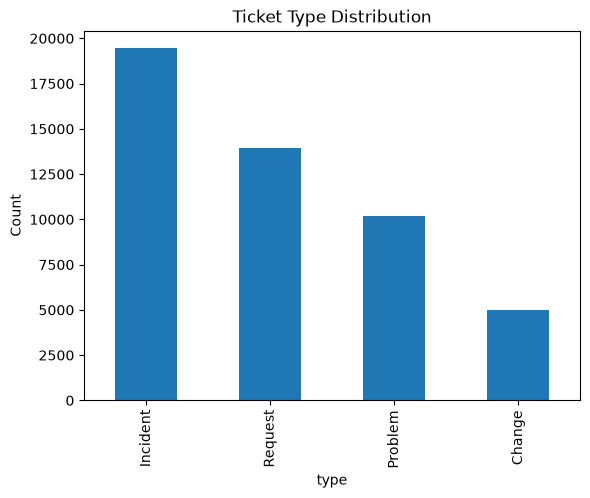

type
Incident    19444
Request     13950
Problem     10196
Change       4997
Name: count, dtype: int64


In [5]:
df["type"].value_counts().plot(kind="bar", title="Ticket Type Distribution")
plt.ylabel("Count")
plt.show()
print(df["type"].value_counts())

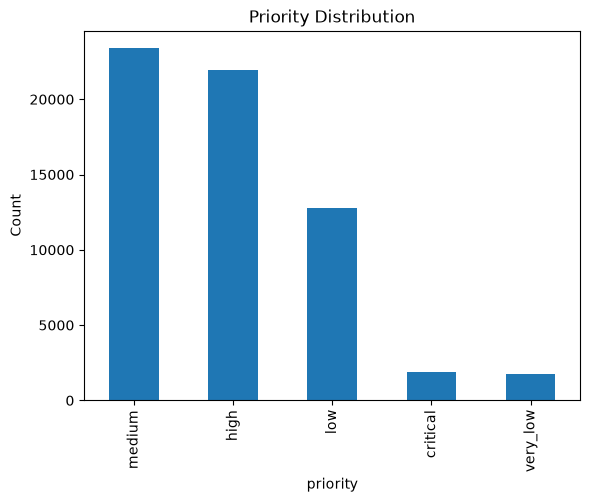

priority
medium      23378
high        21925
low         12765
critical     1914
very_low     1783
Name: count, dtype: int64


In [6]:
df["priority"].value_counts().plot(kind="bar", title="Priority Distribution")
plt.ylabel("Count")
plt.show()
print(df["priority"].value_counts())

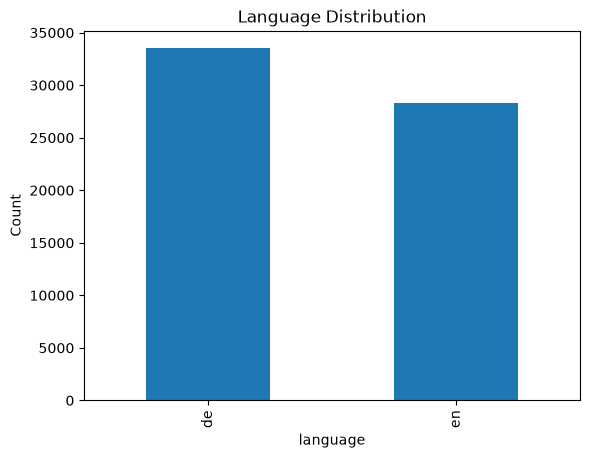

language
de    33504
en    28261
Name: count, dtype: int64


In [7]:
df["language"].value_counts().plot(kind="bar", title="Language Distribution")
plt.ylabel("Count")
plt.show()
print(df["language"].value_counts())

In [8]:

df["body_length"] = df["body"].str.len()
df["body_length"].describe()


count    61763.000000
mean       419.192996
std        223.850690
min          4.000000
25%        234.000000
50%        415.000000
75%        587.000000
max       2259.000000
Name: body_length, dtype: float64

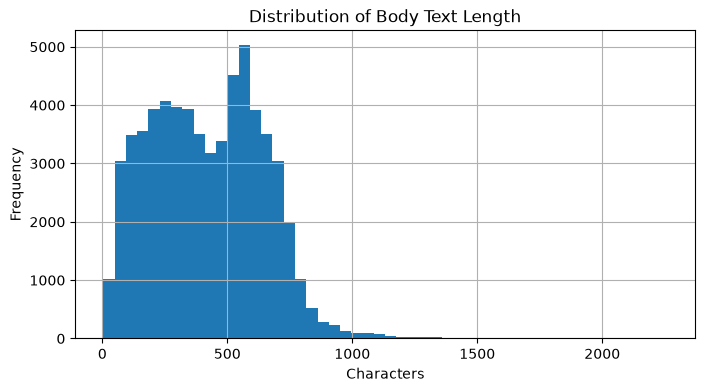

In [9]:
df["body_length"].hist(bins=50, figsize=(8, 4))
plt.title("Distribution of Body Text Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

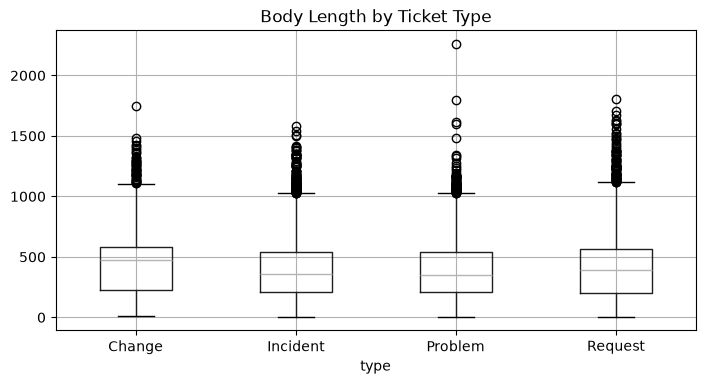

In [10]:
df.boxplot(column="body_length", by="type", figsize=(8, 4))
plt.title("Body Length by Ticket Type")
plt.suptitle("")
plt.show()

In [11]:

def top_words(texts, n=15):
    words = []
    for t in texts.dropna():
        words.extend(re.findall(r"\b[a-z]{3,}\b", t.lower()))
    return [w for w, _ in Counter(words).most_common(n)]

for t in df["type"].unique():
    subset = df[df["type"] == t]["body"]
    print(f"\n--- {t} ---")
    print(top_words(subset, 12))



--- Incident ---
['the', 'and', 'die', 'problem', 'issue', 'und', 'this', 'have', 'software', 'data', 'der', 'das']

--- Request ---
['and', 'the', 'you', 'for', 'und', 'die', 'your', 'ich', 'could', 'would', 'data', 'sie']

--- Problem ---
['the', 'and', 'die', 'problem', 'und', 'issue', 'this', 'have', 'data', 'der', 'software', 'you']

--- Change ---
['and', 'the', 'die', 'und', 'our', 'for', 'data', 'would', 'you', 'this', 'ich', 'der']

--- nan ---
[]


In [14]:
pd.crosstab(df["queue"], df["type"]).iloc[:10, :]

type,Change,Incident,Problem,Request
queue,,,,
Billing and Payments,274,1166,1050,2384
Customer Service,545,1929,1518,3428
General Inquiry,203,208,101,156
Human Resources,59,484,100,271
IT Support,976,2074,1485,1190
Product Support,1058,3829,2034,2039
Returns and Exchanges,311,983,489,655
Sales and Pre-Sales,264,316,205,705
Service Outages and Maintenance,457,1046,124,285



1. **61,765 rows**, 16 columns
2. **4 ticket types:** Incident, Request, Problem, Change these need mapping to our 5 categories (Day 5)
3. **Priority is imbalanced:** medium (23K) > high (22K) > low (13K) > critical (2K)
4. **Body text** averages ~420 characters short enough for fast TF-IDF
5. **Language:** ~54% German, ~46% English we'll filter to English later
6. **Queue has 50+ subcategories** too granular, our 5-category mapping is the right approach